# RT-2 Toy Implementation



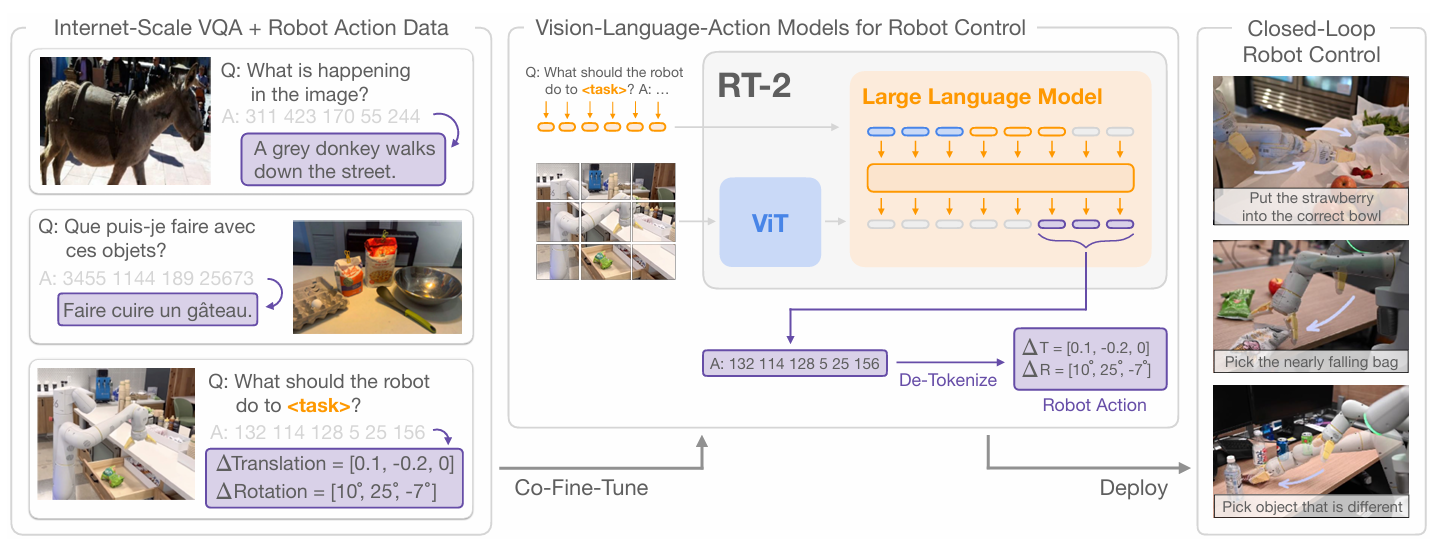

###### 이미지 출처 : Zitkovich, Brianna, et al. "Rt-2: Vision-language-action models transfer web knowledge to robotic control." Conference on Robot Learning. PMLR, 2023.

## 핵심 구현
- robot action을 text token으로 표현함.
- image + instruction prompt에서 action token sequence를 생성함.
- VQA sample과 robot action sample을 같은 seq2seq loss로 mixed training함.
- robot inference에서 valid action token만 허용하는 constrained decoding을 구현함.

## 논문과 다른 점
- PaLI-X/PaLM-E가 아니라 작은 ViT-GPT2 image-captioning 모델을 사용함.
- 본 논문의 6DoF robot action이 아니라 Language-Table 기반 2D action(dx, dy)만 예측함.
- 논문 본 실험의 256-bin discretization과 달리 21-bin discretization을 사용함.
- Web-scale VQA/captioning mixture가 아니라 소규모 simpleVQA와 Language-Table subset만 사용함.
- Language-Table 논문 실험의 multi-task prediction 구성은 구현하지 않고 action prediction 중심으로 구성함.
- closed-loop control rollout은 구현하지 않았고, single-step action token prediction만 평가함.



# Settings

In [1]:
# === 기본 설치 ===
!pip install -q tensorflow tensorflow-datasets
!pip install -q matplotlib

# === VQA dataset ===
!pip install -q datasets

# === 모델 라이브러리 ===
!pip install -q transformers accelerate
!pip install -q pillow

In [2]:
# === 기본 라이브러리 ===
import tensorflow as tf
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import re
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# === 모델 ===
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from torch.optim import AdamW

# === 로봇 데이터셋 ===
import tensorflow_datasets as tfds

# === VQA 데이터셋 ===
from datasets import load_dataset

# === data 통합 ===
from torch.utils.data import ConcatDataset
from torch.utils.data import Dataset, DataLoader, ConcatDataset, random_split

## Dataset Loading

In [3]:
# === Language Table ===
# simple Robot Action dataset
data_directory = "gs://gresearch/robotics/language_table/0.0.1/"
builder = tfds.builder_from_directory(data_directory)
ds = builder.as_dataset(split="train")

# === simple VQA dataset ===
vqa_raw = load_dataset("JosephFace/simpleVQA", split="train")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/252k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/128 [00:00<?, ? examples/s]

In [4]:
def extract_instruction(step):
    arr = step["observation"]["instruction"].numpy()
    arr = arr[arr != 0]
    return "".join(chr(x) for x in arr)

In [5]:
# === 실제 데이터 확인 ===
for sample in ds.take(1):
    steps = sample["steps"]
    for step in steps.take(3):
        instruction = extract_instruction(step)
        print("instruction:", instruction)
        print("action:", step["action"].numpy())
        print("image shape:", step["observation"]["rgb"].shape)
        print("-" * 50)

instruction: place your arm right to blue triangle
action: [-0.03405493  0.05285302]
image shape: (360, 640, 3)
--------------------------------------------------
instruction: place your arm right to blue triangle
action: [-0.03159216  0.06587997]
image shape: (360, 640, 3)
--------------------------------------------------
instruction: place your arm right to blue triangle
action: [-0.03985721  0.05947573]
image shape: (360, 640, 3)
--------------------------------------------------


In [6]:
DX_MIN, DX_MAX = -0.12, 0.17
DY_MIN, DY_MAX = -0.22, 0.18
NUM_BINS = 21

SEED = 42

In [7]:
# ------------------------------------------------------------
# Action tokenization and prompt utilities
# ------------------------------------------------------------
# RT-2 represents robot actions as text tokens.
# This toy implementation follows the same idea, but uses only
# 2D Language-Table actions:
#   action = [dx, dy]
#
# Important difference from the main RT-2 robot experiments:
# - RT-2 main robot setting uses 256 bins for continuous actions.
# - This toy implementation uses 21 bins because Language-Table
#   actions are small 2D Cartesian movements.


def value_to_bin(v, vmin, vmax, num_bins=NUM_BINS):
    """Convert a continuous scalar action value into a discrete bin index."""
    v = np.clip(v, vmin, vmax)
    ratio = (v - vmin) / (vmax - vmin)
    idx = int(round(ratio * (num_bins - 1)))
    idx = max(0, min(num_bins - 1, idx))
    return idx


def bin_to_value(idx, vmin, vmax, num_bins=NUM_BINS):
    """Convert a discrete bin index back to an approximate continuous value."""
    idx = max(0, min(num_bins - 1, int(idx)))
    ratio = idx / (num_bins - 1)
    value = vmin + ratio * (vmax - vmin)
    return value


def action_to_tokens(dx, dy):
    """Convert 2D continuous action [dx, dy] into two action tokens."""
    bx = value_to_bin(dx, DX_MIN, DX_MAX)
    by = value_to_bin(dy, DY_MIN, DY_MAX)

    token_x = f"ACTX{bx:02d}"
    token_y = f"ACTY{by:02d}"

    return [token_x, token_y]


def tokens_to_action(token_x, token_y):
    """Convert ACTX/ACTY tokens back into approximate continuous [dx, dy]."""
    bx = int(token_x.replace("ACTX", ""))
    by = int(token_y.replace("ACTY", ""))

    dx = bin_to_value(bx, DX_MIN, DX_MAX)
    dy = bin_to_value(by, DY_MIN, DY_MAX)

    return dx, dy


def build_robot_prompt(instruction):
    """Build the RT-2-style robot action prompt."""
    return f"Q: what action should the robot take to {instruction}? A:"


def build_vqa_prompt(question):
    """Build a VQA prompt with the same Q/A style."""
    return f"Q: {question} A:"


def process_step(step):
    """Convert one Language-Table step into an RT-2-style training sample."""
    image = step["observation"]["rgb"].numpy()
    instruction = extract_instruction(step)

    action = step["action"].numpy()
    dx, dy = float(action[0]), float(action[1])

    tokens = action_to_tokens(dx, dy)
    prompt = build_robot_prompt(instruction)
    target_text = " ".join(tokens)

    return {
        "image": image,
        "prompt": prompt,
        "target_text": target_text,
        "task_type": "robot",
        "target_tokens": tokens,
        "raw_action": np.array([dx, dy], dtype=np.float32),
        "instruction": instruction,
    }

In [8]:
# ------------------------------------------------------------
# Robot action dataset
# ------------------------------------------------------------
# This dataset converts Language-Table trajectory steps into
# RT-2-style samples:
#   image + robot instruction prompt -> ACTX / ACTY action tokens.

class RT2Dataset(Dataset):
    def __init__(self, tf_dataset, max_samples=1000):
        self.samples = []

        count = 0
        for episode in tf_dataset:
            steps = episode["steps"]

            for step in steps:
                if count >= max_samples:
                    return

                processed = process_step(step)
                self.samples.append(processed)
                count += 1

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

In [9]:
# ------------------------------------------------------------
# VQA dataset
# ------------------------------------------------------------
# This dataset converts SimpleVQA samples into the same seq2seq
# format as robot samples:
#   image + question prompt -> natural-language answer.
#
# This is the toy version of RT-2 co-fine-tuning:
# robot action prediction and VQA are trained with the same
# next-token prediction objective.

class VQADataset(Dataset):
    def __init__(self, hf_dataset, max_samples=128):
        self.samples = []

        for i in range(min(len(hf_dataset), max_samples)):
            item = hf_dataset[i]

            messages = item["messages"]

            question = messages[0]["content"]
            answer = messages[1]["content"]

            image = item["image"].convert("RGB")

            prompt = build_vqa_prompt(question)
            target_text = answer

            self.samples.append({
                "image": image,
                "prompt": prompt,
                "target_text": target_text,
                "task_type": "vqa",
                "question": question,
                "answer": answer,
                "image_path": item.get("image_path", None),
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

In [10]:
# Sanity check for the VQA wrapper.

vqa_dataset = VQADataset(vqa_raw, max_samples=10)

print("VQA dataset size:", len(vqa_dataset))
print(vqa_dataset[0].keys())
print("task_type:", vqa_dataset[0]["task_type"])
print("prompt:", vqa_dataset[0]["prompt"])
print("target_text:", vqa_dataset[0]["target_text"])
print("image type:", type(vqa_dataset[0]["image"]))

VQA dataset size: 10
dict_keys(['image', 'prompt', 'target_text', 'task_type', 'question', 'answer', 'image_path'])
task_type: vqa
prompt: Q: What is shown in this image? A:
target_text: This is sample image 0 from the SimpleVQA dataset.
image type: <class 'PIL.Image.Image'>


### Dataset Construction and Sanity Check

In [11]:
# === 변환 테스트 ===

for sample in ds.take(1):
    steps = sample["steps"]

    for step in steps.take(3):
        result = process_step(step)

        print("PROMPT:")
        print(result["prompt"])

        print("TARGET:")
        print(result["target_tokens"])

        print("-" * 50)

PROMPT:
Q: what action should the robot take to place your arm right to blue triangle? A:
TARGET:
['ACTX06', 'ACTY14']
--------------------------------------------------
PROMPT:
Q: what action should the robot take to place your arm right to blue triangle? A:
TARGET:
['ACTX06', 'ACTY14']
--------------------------------------------------
PROMPT:
Q: what action should the robot take to place your arm right to blue triangle? A:
TARGET:
['ACTX06', 'ACTY14']
--------------------------------------------------


In [12]:
robot_dataset_check = RT2Dataset(ds, max_samples=128)

print("Dataset size:", len(robot_dataset_check))
print("First instruction:", robot_dataset_check[0]["instruction"])
print("First raw action:", robot_dataset_check[0]["raw_action"])
print("First target tokens:", robot_dataset_check[0]["target_tokens"])

print(robot_dataset_check[0].keys())
print(robot_dataset_check[0]["task_type"])
print(robot_dataset_check[0]["prompt"])
print(robot_dataset_check[0]["target_text"])
print(robot_dataset_check[0]["target_tokens"])

Dataset size: 128
First instruction: place your arm right to blue triangle
First raw action: [-0.03405493  0.05285302]
First target tokens: ['ACTX06', 'ACTY14']
dict_keys(['image', 'prompt', 'target_text', 'task_type', 'target_tokens', 'raw_action', 'instruction'])
robot
Q: what action should the robot take to place your arm right to blue triangle? A:
ACTX06 ACTY14
['ACTX06', 'ACTY14']


In [13]:
# ------------------------------------------------------------
# Mixed dataset: Robot action data + VQA data
# ------------------------------------------------------------
# RT-2's key training recipe is co-fine-tuning:
#   robot action prediction + vision-language tasks.
#
# This toy implementation approximates that idea using:
#   - Language-Table robot action samples
#   - SimpleVQA samples
#
# Both are converted into the same format:
#   image + prompt -> target_text
#
# Train/test split for robot and VQA datasets
# - Training uses only train split.
# - Demo and evaluation use test split.
# - This avoids evaluating on samples already used during training.


robot_dataset = RT2Dataset(ds, max_samples=128)
vqa_dataset = VQADataset(vqa_raw, max_samples=128)

robot_train_size = int(0.8 * len(robot_dataset))
robot_test_size = len(robot_dataset) - robot_train_size

robot_train_dataset, robot_test_dataset = random_split(
    robot_dataset,
    [robot_train_size, robot_test_size],
    generator=torch.Generator().manual_seed(SEED)
)

vqa_train_size = int(0.8 * len(vqa_dataset))
vqa_test_size = len(vqa_dataset) - vqa_train_size

vqa_train_dataset, vqa_test_dataset = random_split(
    vqa_dataset,
    [vqa_train_size, vqa_test_size],
    generator=torch.Generator().manual_seed(SEED)
)

mixed_train_dataset = ConcatDataset([
    robot_train_dataset,
    vqa_train_dataset
])

print("Robot dataset:", len(robot_dataset))
print("Robot train:", len(robot_train_dataset))
print("Robot test:", len(robot_test_dataset))

print("VQA dataset:", len(vqa_dataset))
print("VQA train:", len(vqa_train_dataset))
print("VQA test:", len(vqa_test_dataset))

print("Mixed train dataset:", len(mixed_train_dataset))

Robot dataset: 128
Robot train: 102
Robot test: 26
VQA dataset: 128
VQA train: 102
VQA test: 26
Mixed train dataset: 204


## Model and Tokenizer Setup

In [14]:
# ------------------------------------------------------------
# Load a small vision-language model
# ------------------------------------------------------------
# The original RT-2 uses large PaLI-X / PaLM-E models.
# This toy implementation uses a much smaller ViT-GPT2
# image-captioning model for Colab feasibility.

model_name = "nlpconnect/vit-gpt2-image-captioning"

model = VisionEncoderDecoderModel.from_pretrained(model_name)
processor = ViTImageProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

In [15]:
# ------------------------------------------------------------
# Add action tokens to the tokenizer
# ------------------------------------------------------------
# RT-2 maps discretized robot actions into the language-token space.
# Here, we explicitly add ACTX** and ACTY** tokens to the tokenizer.
#
# After adding tokens, the decoder embedding matrix must be resized.


AX_tokens = [f"ACTX{i:02d}" for i in range(NUM_BINS)]
AY_tokens = [f"ACTY{i:02d}" for i in range(NUM_BINS)]

new_tokens = AX_tokens + AY_tokens
tokenizer.add_special_tokens({"additional_special_tokens": new_tokens})

# 모델 embedding 크기 맞추기
model.decoder.resize_token_embeddings(len(tokenizer))

# === action token ids ===
ACTX_TOKEN_IDS = tokenizer.convert_tokens_to_ids(AX_tokens)
ACTY_TOKEN_IDS = tokenizer.convert_tokens_to_ids(AY_tokens)

print(ACTX_TOKEN_IDS[:3], ACTX_TOKEN_IDS[-3:])
print(ACTY_TOKEN_IDS[:3], ACTY_TOKEN_IDS[-3:])

print("Added tokens:", len(new_tokens))

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


[50257, 50258, 50259] [50275, 50276, 50277]
[50278, 50279, 50280] [50296, 50297, 50298]
Added tokens: 42


In [16]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
# === special token 설정하기 ===
model.config.decoder_start_token_id = tokenizer.bos_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id

In [17]:
# Sanity check:
# Confirm that each action token is treated as a single token.
# This is important because robot actions should be generated as
# discrete action symbols, not split into subword pieces.

print(tokenizer.tokenize("ACTX08"))
print(tokenizer.tokenize("ACTY14"))

print(tokenizer("ACTX08 ACTY14", add_special_tokens=False).input_ids)
print(tokenizer.convert_ids_to_tokens(tokenizer("ACTX08 ACTY14", add_special_tokens=False).input_ids))

['ACTX08']
['ACTY14']
[50265, 220, 50292]
['ACTX08', 'Ġ', 'ACTY14']


In [18]:
# ------------------------------------------------------------
# Preprocess one sample for VisionEncoderDecoderModel training
# ------------------------------------------------------------
# Input:
#   sample["image"]       -> encoder input
#   sample["prompt"]      -> decoder prompt
#   sample["target_text"] -> supervised output
#
# The full decoder text is:
#   prompt + target_text
#
# The prompt tokens are masked with -100 so that loss is computed
# only on the target_text part.


def preprocess(sample):
    image = sample["image"]

    if hasattr(image, "convert"):
        image = image.convert("RGB")

    pixel_values = processor(
        images=image,
        return_tensors="pt"
    ).pixel_values.squeeze(0)

    prompt_text = sample["prompt"]
    target_text = sample["target_text"]
    full_text = prompt_text + " " + target_text

    encoded_full = tokenizer(
        full_text,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=96
    )

    labels = encoded_full.input_ids.squeeze(0)

    encoded_prompt = tokenizer(
        prompt_text,
        return_tensors="pt",
        add_special_tokens=False
    )

    prompt_len = encoded_prompt.input_ids.shape[1]

    labels = labels.clone()
    labels[:prompt_len] = -100

    if tokenizer.pad_token_id is not None:
        labels[labels == tokenizer.pad_token_id] = -100

    return {
        "pixel_values": pixel_values,
        "labels": labels,
        "decoder_attention_mask": encoded_full.attention_mask.squeeze(0)
    }

# Training Dataset and DataLoader

In [19]:
# === 데이터 wrapper ===
class TorchRT2Dataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        return preprocess(self.base[idx])

def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.stack([item["labels"] for item in batch])
    decoder_attention_mask = torch.stack([item["decoder_attention_mask"] for item in batch])

    return {
        "pixel_values": pixel_values,
        "labels": labels,
        "decoder_attention_mask": decoder_attention_mask,
    }

In [20]:
# Wrap the mixed dataset so that each sample is converted into
# model-ready tensors on access.
# DataLoader for train split only.
# Test split is reserved for inference/evaluation.

torch_dataset = TorchRT2Dataset(mixed_train_dataset)
loader = DataLoader(torch_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)

# Optimizer and Forward-Pass Check

In [21]:
# Move model to device and define optimizer.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
optimizer = AdamW(model.parameters(), lr=5e-5)

In [22]:
# Forward-pass sanity check.
# This verifies that:
#   - images are processed correctly,
#   - decoder labels are valid,
#   - added action-token embeddings are compatible with the model.

batch = next(iter(loader))

decoder_attention_mask = batch["decoder_attention_mask"].to(device)
pixel_values = batch["pixel_values"].to(device)
labels = batch["labels"].to(device)
outputs = model(
    pixel_values=pixel_values,
    labels=labels,
    decoder_attention_mask=decoder_attention_mask
)

print("Loss:", outputs.loss)

Loss: tensor(7.7475, device='cuda:0', grad_fn=<NllLossBackward0>)


## Training

In [23]:
num_epochs = 100

In [24]:
# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------
# This trains the model with a standard next-token prediction loss.
# For robot samples, the model learns to generate action tokens.
# For VQA samples, the model learns to generate natural-language answers.

model.train()

for epoch in range(num_epochs):
    total_loss = 0

    for batch in loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        decoder_attention_mask = batch["decoder_attention_mask"].to(device)

        outputs = model(
            pixel_values=pixel_values,
            labels=labels,
            decoder_attention_mask=decoder_attention_mask
        )

        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

Epoch 1 Loss: 3.3033
Epoch 2 Loss: 1.7883
Epoch 3 Loss: 1.5809
Epoch 4 Loss: 1.2353
Epoch 5 Loss: 0.8640
Epoch 6 Loss: 0.6442
Epoch 7 Loss: 0.6038
Epoch 8 Loss: 0.5939
Epoch 9 Loss: 0.5582
Epoch 10 Loss: 0.5705
Epoch 11 Loss: 0.5742
Epoch 12 Loss: 0.5477
Epoch 13 Loss: 0.5611
Epoch 14 Loss: 0.5621
Epoch 15 Loss: 0.5535
Epoch 16 Loss: 0.5744
Epoch 17 Loss: 0.5468
Epoch 18 Loss: 0.5207
Epoch 19 Loss: 0.5079
Epoch 20 Loss: 0.4896
Epoch 21 Loss: 0.4884
Epoch 22 Loss: 0.4776
Epoch 23 Loss: 0.4714
Epoch 24 Loss: 0.4622
Epoch 25 Loss: 0.4620
Epoch 26 Loss: 0.4609
Epoch 27 Loss: 0.4664
Epoch 28 Loss: 0.4630
Epoch 29 Loss: 0.4457
Epoch 30 Loss: 0.4391
Epoch 31 Loss: 0.4335
Epoch 32 Loss: 0.4330
Epoch 33 Loss: 0.4307
Epoch 34 Loss: 0.4355
Epoch 35 Loss: 0.4134
Epoch 36 Loss: 0.4021
Epoch 37 Loss: 0.4026
Epoch 38 Loss: 0.3755
Epoch 39 Loss: 0.3749
Epoch 40 Loss: 0.3660
Epoch 41 Loss: 0.3568
Epoch 42 Loss: 0.3526
Epoch 43 Loss: 0.3485
Epoch 44 Loss: 0.3458
Epoch 45 Loss: 0.3373
Epoch 46 Loss: 0.32

## Evaluation and Inference

In [25]:
# ------------------------------------------------------------
# Common inference utilities
# ------------------------------------------------------------

def extract_action_tokens(text):
    """Extract ACTX/ACTY tokens from generated text."""
    return re.findall(r"ACTX\d{2}|ACTY\d{2}", text)


def safe_tokens_to_action(tokens):
    """Safely convert extracted action tokens into a continuous action."""
    if len(tokens) < 2:
        return None

    ax_token = None
    ay_token = None

    for t in tokens:
        if t.startswith("ACTX") and ax_token is None:
            ax_token = t
        elif t.startswith("ACTY") and ay_token is None:
            ay_token = t

    if ax_token is None or ay_token is None:
        return None

    return tokens_to_action(ax_token, ay_token)

def masked_argmax(logits, allowed_token_ids):
    """Return the argmax token id after masking out invalid tokens."""
    mask = torch.full_like(logits, float("-inf"))
    mask[allowed_token_ids] = logits[allowed_token_ids]
    return torch.argmax(mask).item()

In [26]:
# ------------------------------------------------------------
# Unconstrained text generation
# ------------------------------------------------------------
# This is useful for checking whether the model can generate VQA
# answers or action-like text. However, for robot control, this is
# not sufficient because the model may generate invalid non-action text.

def predict(sample, max_new_tokens=6):
    model.eval()

    with torch.no_grad():
        pixel_values = processor(
            images=sample["image"],
            return_tensors="pt"
        ).pixel_values.to(device)

        prompt = sample["prompt"]
        input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

        outputs = model.generate(
            pixel_values=pixel_values,
            decoder_input_ids=input_ids,
            max_new_tokens=max_new_tokens,
            num_beams=1,
            do_sample=False
        )

        text = tokenizer.decode(outputs[0], skip_special_tokens=False)

    return text


def predict_text(sample, max_new_tokens=30):
    """General text generation for VQA-style samples."""
    return predict(sample, max_new_tokens=max_new_tokens)

In [27]:
# ------------------------------------------------------------
# Masked robot action inference
# ------------------------------------------------------------
# RT-2 constrains decoding during robot-action inference so that
# only valid action tokens can be generated.
#
# In this toy setting:
#   first action token  -> one of ACTX**
#   second action token -> one of ACTY**

def predict_robot_action_masked(sample):
    model.eval()

    with torch.no_grad():
        pixel_values = processor(
            images=sample["image"],
            return_tensors="pt"
        ).pixel_values.to(device)

        prompt = sample["prompt"]
        decoder_input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

        # ACTX
        outputs = model(
            pixel_values=pixel_values,
            decoder_input_ids=decoder_input_ids
        )
        logits = outputs.logits[0, -1, :]
        actx_id = masked_argmax(logits, ACTX_TOKEN_IDS)

        decoder_input_ids = torch.cat([
            decoder_input_ids,
            torch.tensor([[actx_id]], device=device)
        ], dim=1)

        # space
        space_id = tokenizer(" ", add_special_tokens=False).input_ids[0]
        decoder_input_ids = torch.cat([
            decoder_input_ids,
            torch.tensor([[space_id]], device=device)
        ], dim=1)

        # ACTY
        outputs = model(
            pixel_values=pixel_values,
            decoder_input_ids=decoder_input_ids
        )
        logits = outputs.logits[0, -1, :]
        acty_id = masked_argmax(logits, ACTY_TOKEN_IDS)

        decoder_input_ids = torch.cat([
            decoder_input_ids,
            torch.tensor([[acty_id]], device=device)
        ], dim=1)

        pred_tokens = [
            tokenizer.convert_ids_to_tokens(actx_id),
            tokenizer.convert_ids_to_tokens(acty_id)
        ]

        pred_action = tokens_to_action(pred_tokens[0], pred_tokens[1])

    return {
        "pred_tokens": pred_tokens,
        "pred_action": pred_action
    }



In [28]:
# ------------------------------------------------------------
# Visualization and qualitative inspection utilities
# ------------------------------------------------------------

def show_prediction_result(sample):
    # 1) 이미지 표시
    plt.figure(figsize=(8, 5))
    plt.imshow(sample["image"])
    plt.axis("off")
    plt.show()

    # 2) 기본 정보
    print("Instruction:", sample["instruction"])
    print("Prompt:", sample["prompt"])

    # 3) GT 정보
    print("\n[GT]")
    print("Raw action:", sample["raw_action"])
    print("Target tokens:", sample["target_tokens"])

    gt_recon = tokens_to_action(sample["target_tokens"][0], sample["target_tokens"][1])
    print("Reconstructed GT action:", gt_recon)

    # 4) 예측
    pred_text = predict(sample)
    pred_tokens = extract_action_tokens(pred_text)
    pred_recon = safe_tokens_to_action(pred_tokens)

    print("\n[Prediction]")
    print("Raw pred text:", pred_text)
    print("Pred tokens:", pred_tokens)
    print("Reconstructed pred action:", pred_recon)

def show_robot_masked_prediction(sample):
    plt.figure(figsize=(8, 5))
    plt.imshow(sample["image"])
    plt.axis("off")
    plt.show()

    print("Instruction:", sample["instruction"])

    print("\n[GT]")
    print("Raw:", sample["raw_action"])
    print("Tokens:", sample["target_tokens"])

    result = predict_robot_action_masked(sample)

    print("\n[Masked Prediction]")
    print("Tokens:", result["pred_tokens"])
    print("Action:", result["pred_action"])

In [29]:
# ------------------------------------------------------------
# Evaluation with unconstrained generation
# ------------------------------------------------------------
# This evaluates whether the model can generate the correct ACTX/ACTY
# tokens without action masking.
#
# Important:
# This is not the same as RT-2's valid-action constrained decoding.
# For robot inference, use predict_robot_action_masked().

def evaluate_generation_accuracy(dataset, max_eval_samples=None):
    model.eval()

    total = 0
    correct_x = 0
    correct_y = 0
    correct_both = 0
    invalid = 0

    results = []

    if max_eval_samples is None:
        max_eval_samples = len(dataset)

    for i in tqdm(range(min(len(dataset), max_eval_samples))):
        sample = dataset[i]

        gt_tokens = sample["target_tokens"]  # ["ACTX06", "ACTY14"]

        pred_text = predict(sample)
        pred_tokens = extract_action_tokens(pred_text)

        pred_x = None
        pred_y = None

        for t in pred_tokens:
            if t.startswith("ACTX") and pred_x is None:
                pred_x = t
            elif t.startswith("ACTY") and pred_y is None:
                pred_y = t

        total += 1

        if pred_x is None or pred_y is None:
            invalid += 1
            results.append({
                "idx": i,
                "instruction": sample["instruction"],
                "gt_tokens": gt_tokens,
                "pred_tokens": pred_tokens,
                "pred_text": pred_text,
                "valid": False,
            })
            continue

        x_ok = pred_x == gt_tokens[0]
        y_ok = pred_y == gt_tokens[1]

        correct_x += int(x_ok)
        correct_y += int(y_ok)
        correct_both += int(x_ok and y_ok)

        results.append({
            "idx": i,
            "instruction": sample["instruction"],
            "gt_tokens": gt_tokens,
            "pred_tokens": [pred_x, pred_y],
            "pred_text": pred_text,
            "valid": True,
            "x_ok": x_ok,
            "y_ok": y_ok,
        })

    print("Total samples:", total)
    print("Invalid predictions:", invalid)
    print(f"AX accuracy:   {correct_x / total:.4f}")
    print(f"AY accuracy:   {correct_y / total:.4f}")
    print(f"Both accuracy: {correct_both / total:.4f}")

    return results

# Demo and Sanity Checks

### Demo1 : VQA Prediction

In [30]:
# VQA sample prediction.
sample = vqa_test_dataset[0]

print("Prompt:", sample["prompt"])
print("GT:", sample["target_text"])
print("Pred:", predict_text(sample, max_new_tokens=30))

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


Prompt: Q: What is the main subject of this image? A:
GT: Image 98 displays geometric patterns and visual content.
Pred: <|endoftext|>Q: What is the main subject of this image? A: Image 63 displays geometric patterns and visual content. Image 63 displays geometric patterns and visual content. Image 63 displays geometric patterns and visual content. Image 63 displays


### Demo 2 : Robot unmasked prediction

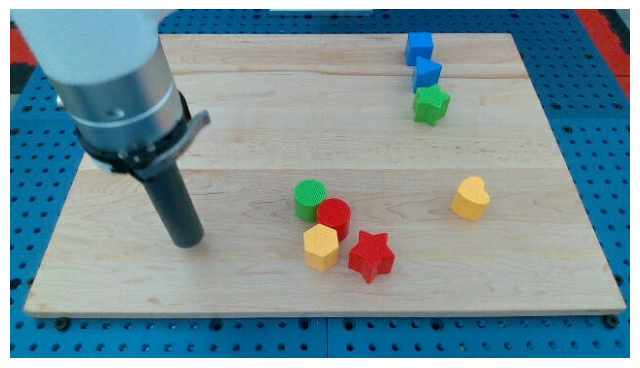

Instruction: move the arm towards the bottom center
Prompt: Q: what action should the robot take to move the arm towards the bottom center? A:

[GT]
Raw action: [-0.01941484  0.0828331 ]
Target tokens: ['ACTX07', 'ACTY15']
Reconstructed GT action: (-0.01849999999999999, 0.08000000000000004)

[Prediction]
Raw pred text: <|endoftext|>Q: what action should the robot take to move the arm towards the bottom center? A: ACTX06 ACTY14 ACTY14
Pred tokens: ['ACTX06', 'ACTY14', 'ACTY14']
Reconstructed pred action: (-0.03299999999999999, 0.05999999999999997)


In [31]:
# Robot sample prediction with unconstrained generation.
show_prediction_result(robot_test_dataset[0])

### Demo3 : robot masked prediction

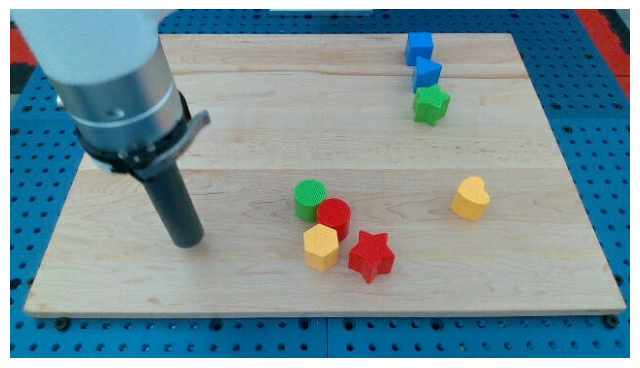

Instruction: move the arm towards the bottom center

[GT]
Raw: [-0.01941484  0.0828331 ]
Tokens: ['ACTX07', 'ACTY15']

[Masked Prediction]
Tokens: ['ACTX06', 'ACTY14']
Action: (-0.03299999999999999, 0.05999999999999997)


In [32]:
# Robot sample prediction with valid-action constrained decoding.
show_robot_masked_prediction(robot_test_dataset[0])

### Demo4 : Robot dataset evaluation

In [33]:
# Quantitative evaluation on robot samples using unconstrained generation.
eval_results = evaluate_generation_accuracy(robot_test_dataset)

100%|██████████| 26/26 [00:03<00:00,  8.57it/s]

Total samples: 26
Invalid predictions: 0
AX accuracy:   0.3077
AY accuracy:   0.4615
Both accuracy: 0.2692
